In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\PBI\Kimia Farma Bid Data Analytics\Assignment\Rakamin_KF_Analytics.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2700663 entries, 0 to 2700662
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   trans_id                 str    
 1   date                     str    
 2   branch_id                int64  
 3   branch_name              str    
 4   kota                     str    
 5   prov                     str    
 6   branch_rating            float64
 7   customer_name            str    
 8   prod_id                  str    
 9   prod_name                str    
 10  actual_price             int64  
 11  discount_percentage      float64
 12  gross_profit_percentage  float64
 13  nett_sales               float64
 14  nett_profit              float64
 15  trans_rating             float64
dtypes: float64(6), int64(2), str(8)
memory usage: 698.2 MB


In [ ]:
#Changing Date Type
df['date'] = df['date'].dt.strftime('%Y-%m-%d')

# Check Missing

In [6]:
# Count total missing values per column
print(df.isnull().sum())

# View percentage of missing values per column
print((df.isnull().sum() / len(df)) * 100)

trans_id                   0
date                       0
branch_id                  0
branch_name                0
kota                       0
prov                       0
branch_rating              0
customer_name              0
prod_id                    0
prod_name                  0
actual_price               0
discount_percentage        0
gross_profit_percentage    0
nett_sales                 0
nett_profit                0
trans_rating               0
dtype: int64
trans_id                   0.0
date                       0.0
branch_id                  0.0
branch_name                0.0
kota                       0.0
prov                       0.0
branch_rating              0.0
customer_name              0.0
prod_id                    0.0
prod_name                  0.0
actual_price               0.0
discount_percentage        0.0
gross_profit_percentage    0.0
nett_sales                 0.0
nett_profit                0.0
trans_rating               0.0
dtype: float64


# Check Dupli

In [7]:
# Count total exact duplicate rows
print(df.duplicated().sum())

# View the actual duplicate rows
print(df[df.duplicated(keep=False)])

# Check duplicates based on specific primary key columns (e.g., transaction_id)
print(df.duplicated(subset=['trans_id']).sum())

2028205
           trans_id        date  branch_id  \
0        TRX4644956  2020-03-14      11079   
1        TRX4644956  2020-03-14      11079   
2        TRX4644956  2020-03-14      11079   
3        TRX6174899  2021-09-10      11079   
4        TRX6174899  2021-09-10      11079   
...             ...         ...        ...   
2700658  TRX4410642  2020-04-22      99997   
2700659  TRX4410642  2020-04-22      99997   
2700660  TRX4410642  2020-04-22      99997   
2700661  TRX4410642  2020-04-22      99997   
2700662  TRX4410642  2020-04-22      99997   

                                      branch_name        kota            prov  \
0                   Kimia Farma - Klinik & Apotek  Purwokerto     Jawa Tengah   
1                   Kimia Farma - Klinik & Apotek  Purwokerto     Jawa Tengah   
2                   Kimia Farma - Klinik & Apotek  Purwokerto     Jawa Tengah   
3                   Kimia Farma - Klinik & Apotek  Purwokerto     Jawa Tengah   
4                   Kimia Farma - 

In [8]:
print(f"Total Rows: {len(df)}")
print(f"Total Duplicates: {df.duplicated().sum()}")
print("\nMissing Values per Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total Rows: 2700663
Total Duplicates: 2028205

Missing Values per Column:
Series([], dtype: int64)


In [ ]:
df[df.duplicated(subset=['trans_id'], keep=False)]

df[df.duplicated(keep=False)].head(5)



,trans_id,date,branch_id,branch_name,kota,prov,branch_rating,customer_name,prod_id,prod_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,trans_rating
0,TRX4644956,2020-03-14,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Crystal Maxwell,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.04,0.2,251599.32,50319.864,3.8
1,TRX4644956,2020-03-14,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Crystal Maxwell,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.04,0.2,251599.32,50319.864,3.8
2,TRX4644956,2020-03-14,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Crystal Maxwell,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.04,0.2,251599.32,50319.864,3.8
3,TRX6174899,2021-09-10,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Pamela Davis,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.03,0.2,251624.49,50324.898,4.0
4,TRX6174899,2021-09-10,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Pamela Davis,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.03,0.2,251624.49,50324.898,4.0


In [13]:
# Keep the first occurrence (default)
df.drop_duplicates(subset=['trans_id'], keep='first', inplace=True)

# Keep the last occurrence
df.drop_duplicates(subset=['trans_id'], keep='last', inplace=True)

# Drop ALL instances of duplicates (leaves no copies)
df.drop_duplicates(subset=['trans_id'], keep=False, inplace=True)

# Confirm 0 duplicates remain
print(df.duplicated(subset=['trans_id']).sum())

0


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 672458 entries, 0 to 2700655
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   trans_id                 672458 non-null  str    
 1   date                     672458 non-null  str    
 2   branch_id                672458 non-null  int64  
 3   branch_name              672458 non-null  str    
 4   kota                     672458 non-null  str    
 5   prov                     672458 non-null  str    
 6   branch_rating            672458 non-null  float64
 7   customer_name            672458 non-null  str    
 8   prod_id                  672458 non-null  str    
 9   prod_name                672458 non-null  str    
 10  actual_price             672458 non-null  int64  
 11  discount_percentage      672458 non-null  float64
 12  gross_profit_percentage  672458 non-null  float64
 13  nett_sales               672458 non-null  float64
 14  nett_profit        

# Outlier check

In [5]:
df = pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\PBI\Kimia Farma Bid Data Analytics\Assignment\Rakamin_KF_Analytics_Cleaned - Copy.csv", low_memory=False)

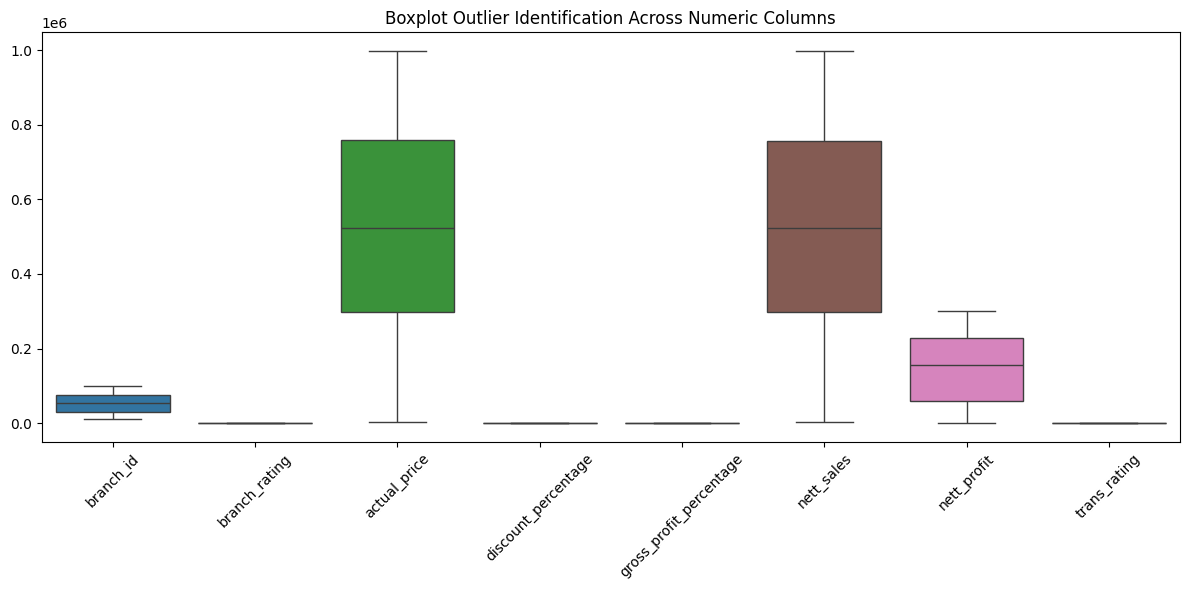

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot Outlier Identification Across Numeric Columns")
plt.tight_layout()
plt.show()

In [6]:
#Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

#Identify outlier rows using the IQR method
outlier_mask = pd.Series(False, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify rows where values in this column are extreme
    col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_mask = outlier_mask | col_outliers

# 4. View and evaluate outlier summary
#otlier_rows = df[outlier_mask]
#clean_rows = df[~outlier_mask]

#print(f"Total rows flagged as outliers: {len(outlier_rows)}")
#print(f"Remaining clean rows: {len(clean_rows)}")

# 5. Save the cleaned dataset (without outliers)
#clean_rows.to_csv("data_no_outliers.csv", index=False)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672458 entries, 0 to 672457
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   trans_id                 672458 non-null  str    
 1   date                     672458 non-null  str    
 2   branch_id                672458 non-null  int64  
 3   branch_name              672458 non-null  str    
 4   kota                     672458 non-null  str    
 5   prov                     672458 non-null  str    
 6   branch_rating            672458 non-null  float64
 7   customer_name            672458 non-null  str    
 8   prod_id                  672458 non-null  str    
 9   prod_name                672458 non-null  str    
 10  actual_price             672458 non-null  int64  
 11  discount_percentage      672458 non-null  float64
 12  gross_profit_percentage  672458 non-null  float64
 13  nett_sales               672458 non-null  float64
 14  nett_profit    

In [9]:
df.head(5)

,trans_id,date,branch_id,branch_name,kota,prov,branch_rating,customer_name,prod_id,prod_name,actual_price,discount_percentage,gross_profit_percentage,nett_sales,nett_profit,trans_rating
0,TRX4644956,2020-03-14,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Crystal Maxwell,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.04,0.2,251599.32,50319.864,3.8
1,TRX6174899,2021-09-10,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Pamela Davis,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.03,0.2,251624.49,50324.898,4.0
2,TRX8884125,2022-12-03,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Bonnie Smith,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.02,0.2,251649.66,50329.932,3.9
3,TRX5135297,2023-03-08,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Susan Daniels,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.02,0.2,251649.66,50329.932,4.7
4,TRX9309792,2020-10-18,11079,Kimia Farma - Klinik & Apotek,Purwokerto,Jawa Tengah,4.7,Edward Lee,KF116,"Psycholeptics drugs, Hypnotics and sedatives d...",251700,0.14,0.2,251347.62,50269.524,4.5
